nx=401  nt=1422  vp=6198 m/s  Courant=0.450
FDM:0.021s  Spectral:0.183s
Saved: fig1  fig2  fig3


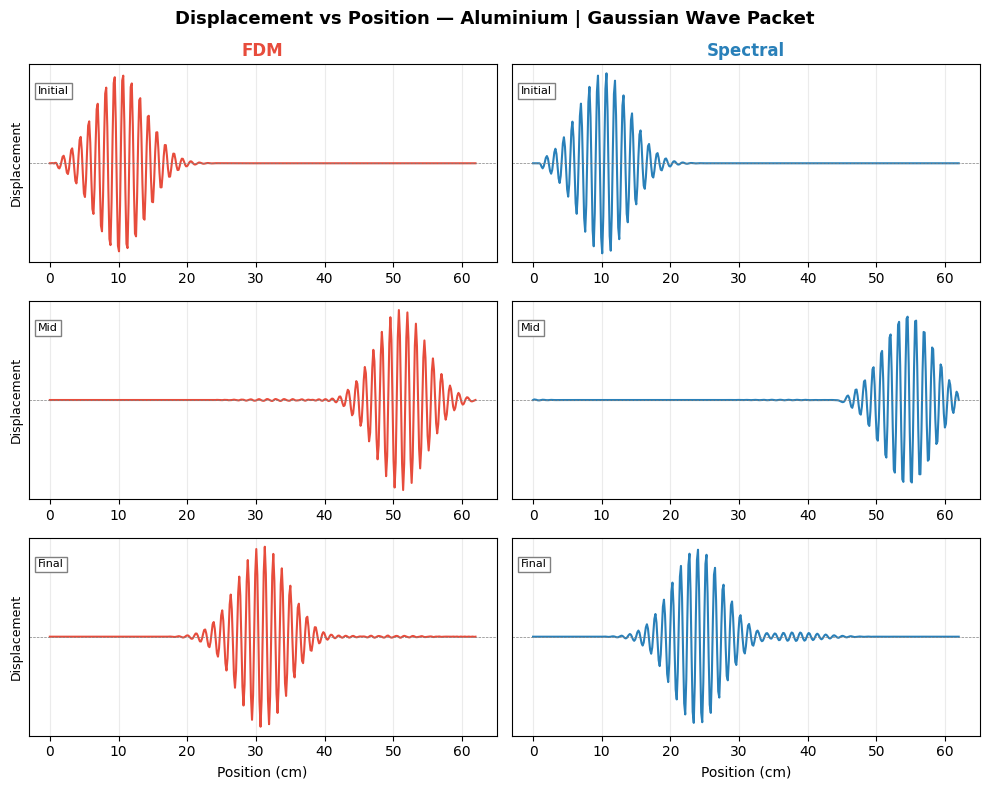

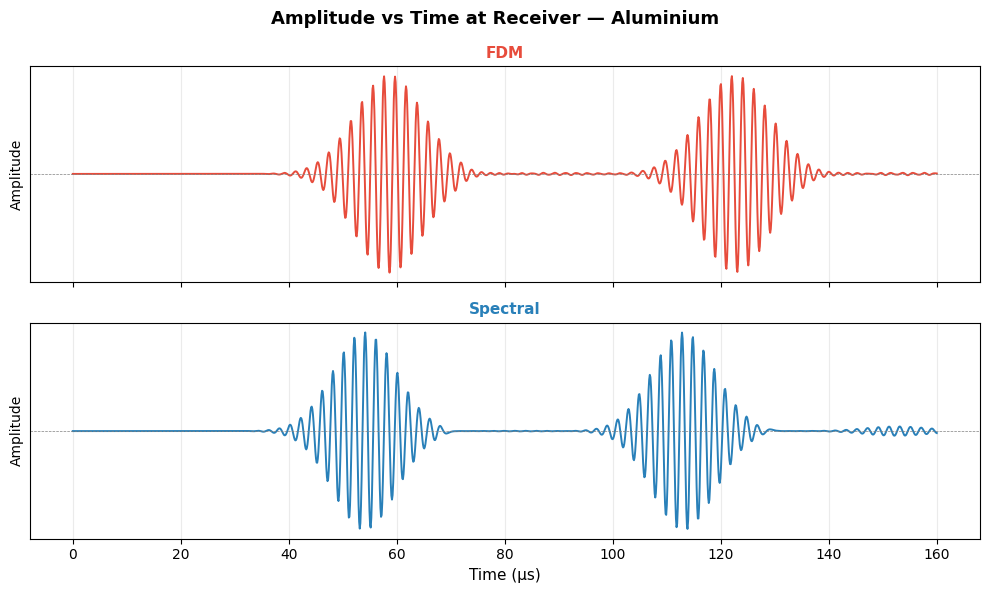

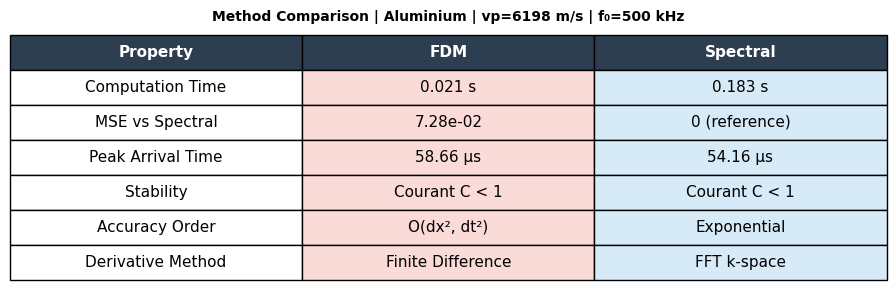

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import time

# ── MEDIUM: Aluminium ──────────────────────────────────────────
rho   = 2700.0
E     = 70e9
nu    = 0.33
vp    = np.sqrt(E*(1-nu) / (rho*(1+nu)*(1-2*nu)))
M_mod = rho * vp**2    # 1D wave modulus — same wave speed for all 3

# ── WAVE: Gaussian wave packet ─────────────────────────────────
f0  = 500e3
lam = vp / f0
sig = 3.0 / f0

def wave_packet(x, x0):
    return np.exp(-((x-x0)**2)/(2*(sig*vp)**2)) * np.sin(2*np.pi*(x-x0)/lam)

# ── GRID ───────────────────────────────────────────────────────
dx   = lam / 8
L    = 50 * lam
nx   = int(L/dx) + 1
dt   = 0.45 * dx / vp
T    = L / vp * 1.6
nt   = int(T / dt)
x    = np.linspace(0, L, nx)
t_us = np.linspace(0, T*1e6, nt)
x0   = L * 0.15
rec  = int(0.70 * nx)
snaps = [int(nt*0.01), int(nt*0.45), int(nt*0.90)]
labs  = ['Initial','Mid','Final']

print(f"nx={nx}  nt={nt}  vp={vp:.0f} m/s  Courant={vp*dt/dx:.3f}")

# ── FDM ────────────────────────────────────────────────────────
C2    = (vp*dt/dx)**2
u     = wave_packet(x, x0)
u_old = wave_packet(x, x0 - vp*dt)
u_new = np.zeros(nx)
fdm_sp=[]; fdm_t=np.zeros(nt)
t0=time.time()
for n in range(nt):
    u_new[1:-1] = 2*u[1:-1] - u_old[1:-1] + C2*(u[2:]-2*u[1:-1]+u[:-2])
    u_new[0]=u_new[-1]=0
    u_old=u.copy(); u=u_new.copy()
    fdm_t[n]=u[rec]
    if n in snaps: fdm_sp.append(u.copy())
time_fdm=time.time()-t0

# ── SPECTRAL ───────────────────────────────────────────────────
k2     = (np.fft.fftfreq(nx,d=dx)*2*np.pi)**2
us     = wave_packet(x, x0)
us_old = wave_packet(x, x0 - vp*dt)
spec_sp=[]; spec_t=np.zeros(nt)
t0=time.time()
for n in range(nt):
    d2u    = np.real(np.fft.ifft(-k2*np.fft.fft(us)))
    us_new = 2*us - us_old + (vp*dt)**2*d2u
    us_new[0]=us_new[-1]=0
    us_old=us.copy(); us=us_new.copy()
    spec_t[n]=us[rec]
    if n in snaps: spec_sp.append(us.copy())
time_spec=time.time()-t0

print(f"FDM:{time_fdm:.3f}s  Spectral:{time_spec:.3f}s")

# ── PLOTS ──────────────────────────────────────────────────────
colors  = ['#E74C3C', '#2980B9']
methods = ['FDM', 'Spectral']
all_sp  = [fdm_sp, spec_sp]
all_t   = [fdm_t,  spec_t]

# Fig 1: Displacement vs Position
fig1, axes = plt.subplots(3, 2, figsize=(10, 8), sharey='row')
fig1.suptitle("Displacement vs Position — Aluminium | Gaussian Wave Packet",
              fontsize=13, fontweight='bold')
for col, (name, sp, c) in enumerate(zip(methods, all_sp, colors)):
    for row, (snap, lab) in enumerate(zip(sp, labs)):
        ax = axes[row, col]
        ax.plot(x*100, snap, color=c, lw=1.5)
        ax.axhline(0, color='gray', lw=0.5, ls='--')
        ax.set_yticks([]); ax.grid(True, alpha=0.25)
        ax.text(0.02, 0.85, lab, transform=ax.transAxes, fontsize=8,
                bbox=dict(fc='white', ec='gray', pad=2))
        if row == 0: ax.set_title(name, fontsize=12, fontweight='bold', color=c)
        if row == 2: ax.set_xlabel("Position (cm)", fontsize=10)
        if col == 0: ax.set_ylabel("Displacement", fontsize=9)
plt.tight_layout()
plt.savefig('fig1_displacement_vs_position.png', dpi=150, bbox_inches='tight')

# Fig 2: Amplitude vs Time
fig2, axes2 = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
fig2.suptitle("Amplitude vs Time at Receiver — Aluminium",
              fontsize=13, fontweight='bold')
for ax, (name, at, c) in zip(axes2, zip(methods, all_t, colors)):
    ax.plot(t_us, at, color=c, lw=1.4)
    ax.axhline(0, color='gray', lw=0.5, ls='--')
    ax.set_ylabel("Amplitude", fontsize=10)
    ax.set_title(name, fontsize=11, fontweight='bold', color=c)
    ax.grid(True, alpha=0.25); ax.set_yticks([])
axes2[-1].set_xlabel("Time (μs)", fontsize=11)
plt.tight_layout()
plt.savefig('fig2_amplitude_vs_time.png', dpi=150, bbox_inches='tight')

# Fig 3: Comparison Table
mse_fdm  = np.mean((fdm_sp[-1] - spec_sp[-1])**2)
peak_fdm = t_us[np.argmax(np.abs(fdm_t))]
peak_spc = t_us[np.argmax(np.abs(spec_t))]

fig3, ax = plt.subplots(figsize=(9, 3))
ax.axis('off')
td = [
    ['Property',          'FDM',                'Spectral'],
    ['Computation Time',  f'{time_fdm:.3f} s',  f'{time_spec:.3f} s'],
    ['MSE vs Spectral',   f'{mse_fdm:.2e}',     '0 (reference)'],
    ['Peak Arrival Time', f'{peak_fdm:.2f} μs', f'{peak_spc:.2f} μs'],
    ['Stability',         'Courant C < 1',      'Courant C < 1'],
    ['Accuracy Order',    'O(dx², dt²)',         'Exponential'],
    ['Derivative Method', 'Finite Difference',  'FFT k-space'],
]
tbl = ax.table(cellText=td[1:], colLabels=td[0], loc='center', cellLoc='center')
tbl.auto_set_font_size(False); tbl.set_fontsize(11); tbl.scale(1.2, 2.1)
for j in range(3):
    tbl[0, j].set_facecolor('#2C3E50')
    tbl[0, j].set_text_props(color='white', fontweight='bold')
for i in range(1, 7):
    for j, c in enumerate(['#FADBD8', '#D6EAF8'], 1):
        tbl[i, j].set_facecolor(c)
ax.set_title(f"Method Comparison | Aluminium | vp={vp:.0f} m/s | f₀={f0/1e3:.0f} kHz",
             fontsize=10, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('fig3_comparison_table.png', dpi=150, bbox_inches='tight')

print("Saved: fig1  fig2  fig3")